In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuro el estilo general de los gráficos
sns.set_theme(style="whitegrid")

# Subo un nivel (../) y entro a la carpeta de la primera actividad
ruta_datos = '../Limpieza-Visualizacion/data/processed/df_financiero_limpio.csv'
df = pd.read_csv(ruta_datos)

# Me aseguro de que la columna fecha sea tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

df.head()

,precio_usd,fecha,nuevos_usuarios,volumen_depositos_usd,retorno_diario
0,67387.661682,2026-04-04,152,52590.41,0.000000
1,67305.532706,2026-04-05,485,54862.98,-0.001219
2,67194.731024,2026-04-05,485,54862.98,-0.001646
3,67097.649997,2026-04-05,485,54862.98,-0.001445
4,67159.488410,2026-04-05,485,54862.98,0.000922


Problema a visualizar: ¿Cómo se comportó el precio de Bitcoin en el periodo de 90 días evaluado?

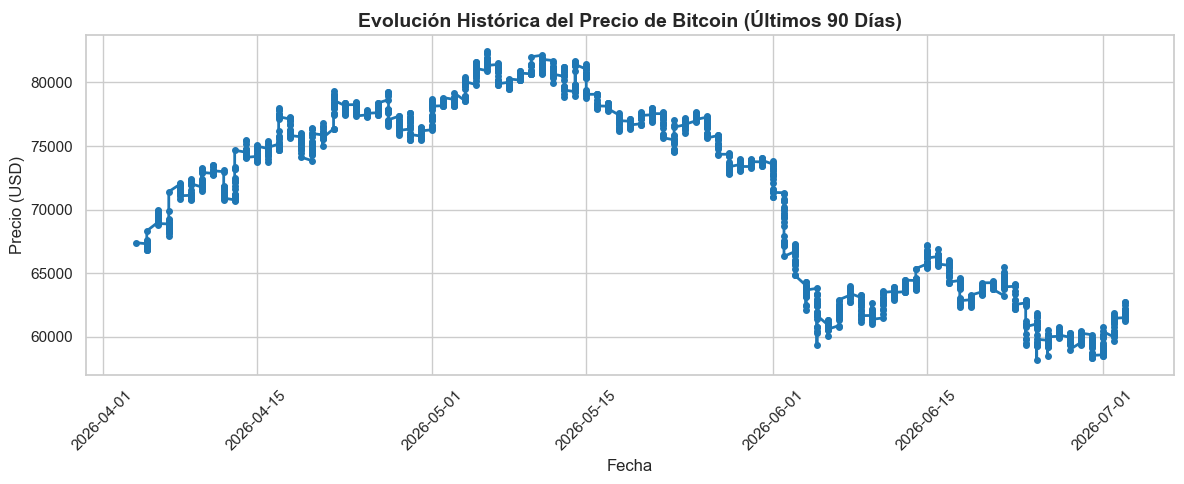

In [ ]:
# Gráfico de líneas para ver la evolución del precio de BTC
plt.figure(figsize=(12, 5))

# Personalizo grosor (linewidth), estilo de línea y marcador
plt.plot(df['fecha'], df['precio_usd'], color='#1f77b4', linewidth=2, linestyle='-', marker='o', markersize=4)

# Etiquetas y títulos claros
plt.title('Evolución Histórica del Precio de Bitcoin (Últimos 90 Días)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)

# Roto las fechas para que no se encimen
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Problema a visualizar: ¿Hay más volumen de depósitos en los días con rendimiento positivo (alcistas) o negativo (bajistas)? Como no tenemos la categoría explícita, primero la voy a derivar.

C:\Users\ivan3\AppData\Local\Temp\ipykernel_30264\439424371.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_agrupado, x='tendencia_dia', y='volumen_depositos_usd', palette=colores)


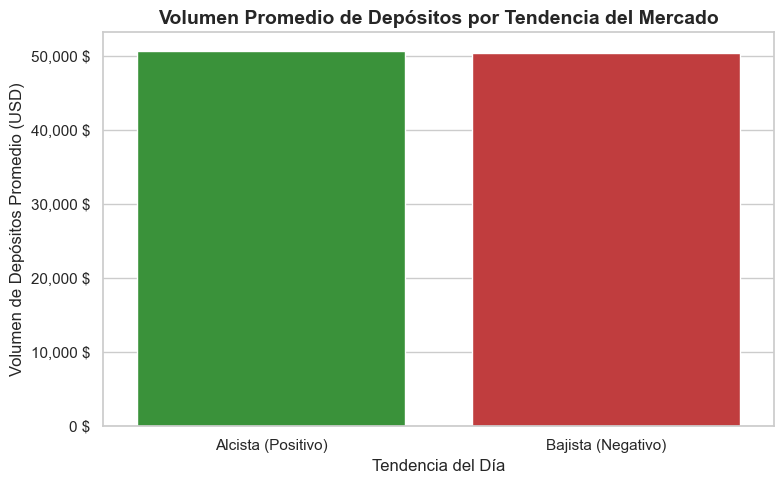

In [8]:
# Creo una nueva columna categórica para identificar si el día fue de ganancias o pérdidas
df['tendencia_dia'] = df['retorno_diario'].apply(lambda x: 'Alcista (Positivo)' if x > 0 else 'Bajista (Negativo)')

# Calculo el promedio de depósitos por cada tendencia
df_agrupado = df.groupby('tendencia_dia')['volumen_depositos_usd'].mean().reset_index()

plt.figure(figsize=(8, 5))

# Uso un gráfico de barras personalizando colores según la categoría (verde para alcista, rojo para bajista)
colores = ['#2ca02c' if tendencia == 'Alcista (Positivo)' else '#d62728' for tendencia in df_agrupado['tendencia_dia']]
sns.barplot(data=df_agrupado, x='tendencia_dia', y='volumen_depositos_usd', palette=colores)

plt.title('Volumen Promedio de Depósitos por Tendencia del Mercado', fontsize=14, fontweight='bold')
plt.xlabel('Tendencia del Día', fontsize=12)
plt.ylabel('Volumen de Depósitos Promedio (USD)', fontsize=12)

# Formateo el eje Y para que parezca dinero
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} $".format(int(x))))

plt.tight_layout()
plt.show()

Problema a visualizar: ¿Existe una relación entre qué tan fuerte es el cambio porcentual diario (volatilidad) y la cantidad de nuevos usuarios que se registran?

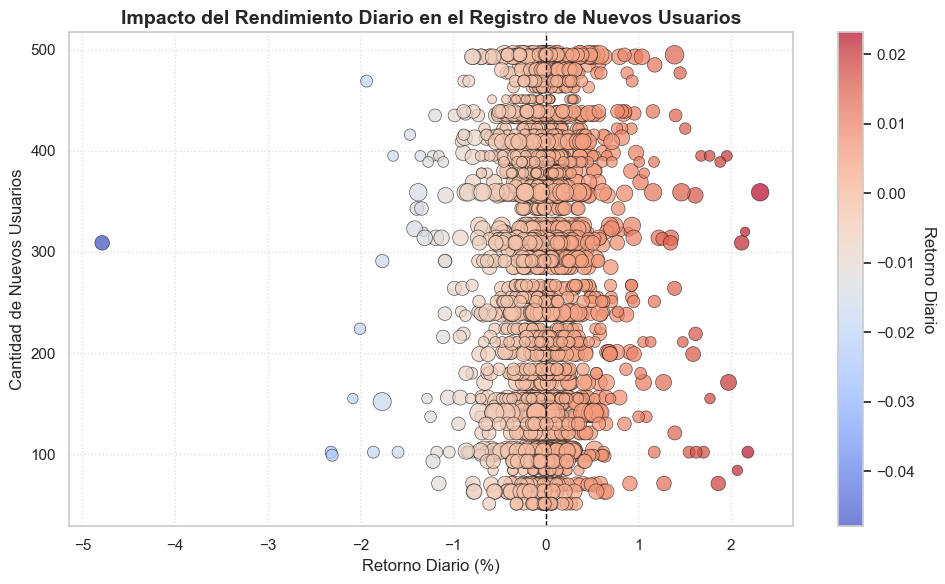

In [9]:
plt.figure(figsize=(10, 6))

# Uso dispersión. El tamaño de los puntos (s) dependerá del volumen de depósitos para dar más contexto (Gráfico de burbujas)
scatter = plt.scatter(x=df['retorno_diario'] * 100, # Lo paso a porcentaje
                      y=df['nuevos_usuarios'], 
                      s=df['volumen_depositos_usd'] / 500, # Escalo el tamaño
                      c=df['retorno_diario'], # El color dependerá del retorno
                      cmap='coolwarm', # Azul para negativo, rojo para positivo
                      alpha=0.7, edgecolors='k', linewidth=0.5)

plt.title('Impacto del Rendimiento Diario en el Registro de Nuevos Usuarios', fontsize=14, fontweight='bold')
plt.xlabel('Retorno Diario (%)', fontsize=12)
plt.ylabel('Cantidad de Nuevos Usuarios', fontsize=12)

# Añado una línea vertical en 0 para separar días de pérdidas y ganancias
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Agrego la barra de color a la derecha para explicar qué significa el color
cbar = plt.colorbar(scatter)
cbar.set_label('Retorno Diario', rotation=270, labelpad=15)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()